# Network Intrusion Detection — NSL-KDD

Comparative analysis of Machine Learning models for multi-class network intrusion
detection, using the **NSL-KDD** dataset.

**Goal:** classify each network connection as `Normal` or as one of 4 attack
families: **DoS**, **Probe**, **R2L**, **U2R**.

**Pipeline:** load & clean data → EDA → encode features → handle class imbalance
(undersampling + SMOTE) → train & compare models → evaluate the best model.

**Author:** Maryame Houssayni — module *Programmation avancée en Python*.


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# Output folders (relative to notebooks/)
IMG_DIR = "../images"
RESULTS_DIR = "../results"
DATA_DIR = "../data"


## 2. Load the data

NSL-KDD ships as headerless text files. We attach the official 41 feature names
plus `attack` (the specific attack label) and `level` (a difficulty score).

In [2]:
COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "level",
]

train = pd.read_csv(f"{DATA_DIR}/KDDTrain+.txt", header=None, names=COLUMNS)
test = pd.read_csv(f"{DATA_DIR}/KDDTest+.txt", header=None, names=COLUMNS)

print("Train:", train.shape)
print("Test :", test.shape)
train.head()


Train: (125973, 43)
Test : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
# Data quality check
print("Missing values (train):", train.isnull().sum().sum())
print("Missing values (test) :", test.isnull().sum().sum())
print("Duplicate rows (train):", train.duplicated().sum())
print("Duplicate rows (test) :", test.duplicated().sum())

train.describe().T


Missing values (train): 0
Missing values (test) : 0


Duplicate rows (train): 0
Duplicate rows (test) : 0


,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


## 3. Exploratory Data Analysis

### 3.1 Map the 23 specific attack labels into 5 categories

`normal` and 22 attack types are grouped into the 4 standard NSL-KDD attack
families. The test set contains a few attack types that never appear in
training (this is intentional in NSL-KDD — it tests generalization to unseen
attacks).

In [4]:
ATTACK_MAP = {
    "normal": "Normal",
    # DoS
    "neptune": "DoS", "back": "DoS", "land": "DoS", "pod": "DoS", "smurf": "DoS",
    "teardrop": "DoS", "processtable": "DoS", "udpstorm": "DoS", "mailbomb": "DoS",
    "apache2": "DoS", "worm": "DoS",
    # Probe
    "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe", "satan": "Probe",
    "saint": "Probe", "mscan": "Probe",
    # R2L
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    "snmpguess": "R2L", "snmpgetattack": "R2L", "named": "R2L", "xlock": "R2L",
    "xsnoop": "R2L", "sendmail": "R2L", "httptunnel": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "sqlattack": "U2R", "xterm": "U2R", "ps": "U2R",
}

for d in (train, test):
    d["attack_category"] = d["attack"].map(ATTACK_MAP)

print("Unmapped labels (train):", train["attack_category"].isna().sum())
print("Unmapped labels (test) :", test["attack_category"].isna().sum())

train["attack_category"].value_counts()


Unmapped labels (train): 0


Unmapped labels (test) : 0


attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

### 3.2 Class distribution

The dataset is strongly imbalanced: `U2R` has only 52 samples out of ~126k.

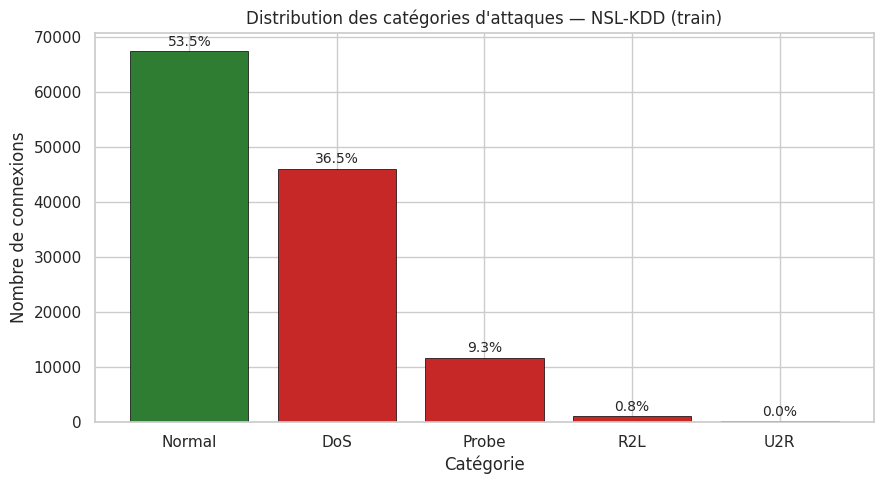

In [5]:
counts = train["attack_category"].value_counts()
pct = train["attack_category"].value_counts(normalize=True) * 100
colors = ["#2e7d32" if c == "Normal" else "#c62828" for c in counts.index]

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=0.5)
for bar, p in zip(bars, pct[counts.index]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
              f"{p:.1f}%", ha="center", va="bottom", fontsize=10)
plt.title("Distribution des catégories d'attaques — NSL-KDD (train)")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de connexions")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/class_distribution.png", dpi=120)
plt.show()


### 3.3 Correlation between numeric features

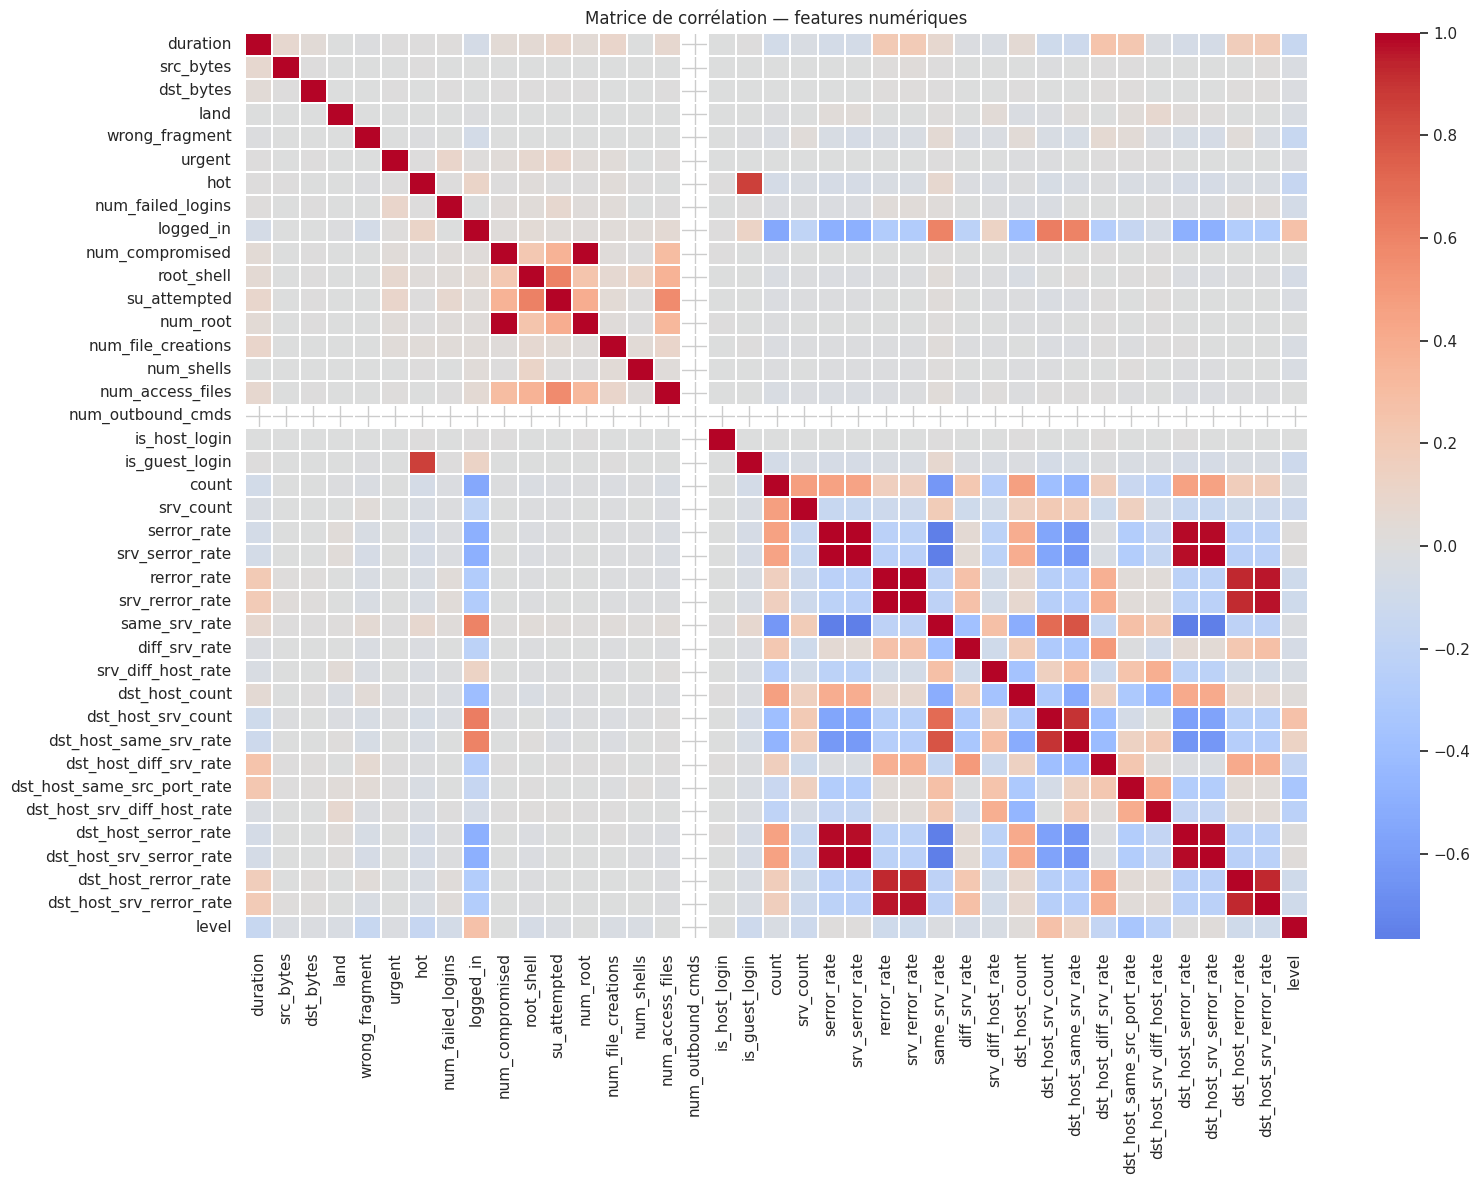

In [6]:
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns
corr = train[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Matrice de corrélation — features numériques")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/correlation_matrix.png", dpi=120)
plt.show()


### 3.4 Connection duration by attack category

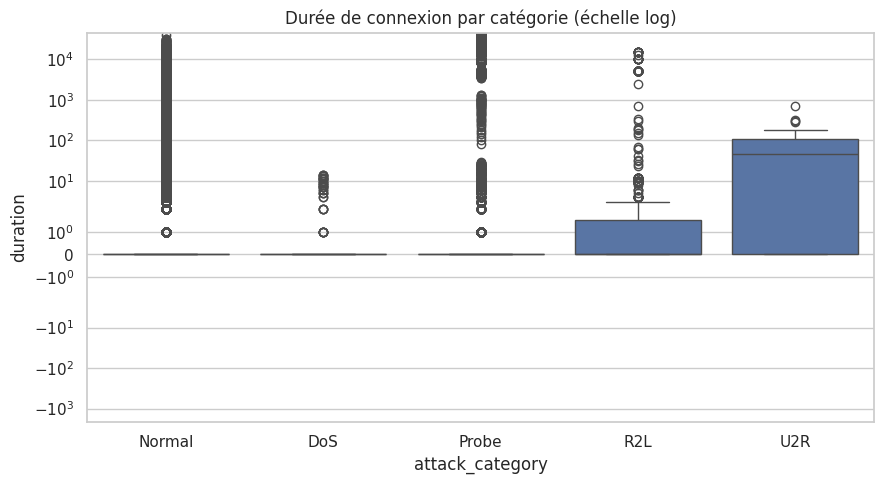

In [7]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=train, x="attack_category", y="duration",
            order=["Normal", "DoS", "Probe", "R2L", "U2R"])
plt.yscale("symlog")
plt.title("Durée de connexion par catégorie (échelle log)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/boxplots_log.png", dpi=120)
plt.show()


## 4. Preprocessing

### 4.1 Encode categorical features

`protocol_type`, `service`, and `flag` are label-encoded. The encoder is fit on
the **train** set only; any category seen in test but not in train is mapped
to a placeholder to avoid errors (a realistic scenario — new services/flags
can appear at inference time).

In [8]:
CAT_COLS = ["protocol_type", "service", "flag"]
encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

    known = set(le.classes_)
    test[col] = test[col].apply(lambda x: x if x in known else le.classes_[0])
    test[col] = le.transform(test[col])

print("Encoded columns:", CAT_COLS)
train[CAT_COLS].head()


Encoded columns: ['protocol_type', 'service', 'flag']


,protocol_type,service,flag
0,1,20,9
1,2,44,9
2,1,49,5
3,1,24,9
4,1,24,9


### 4.2 Encode the target

In [9]:
target_le = LabelEncoder()
train["label"] = target_le.fit_transform(train["attack_category"])
test["label"] = target_le.transform(test["attack_category"])

CLASS_NAMES = list(target_le.classes_)
print("Classes:", CLASS_NAMES)


Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## 5. Features / target split

We drop `attack` (too specific, it's the source of the target), `attack_category`
(the target itself before encoding) and `level` (a severity score derived from
`attack` — keeping it would leak information about the label).

In [10]:
DROP_COLS = ["attack", "attack_category", "level", "label"]

X_train = train.drop(columns=DROP_COLS)
y_train = train["label"]
X_test = test.drop(columns=DROP_COLS)
y_test = test["label"]

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape, " y_test :", y_test.shape)


X_train: (125973, 41)  y_train: (125973,)
X_test : (22544, 41)  y_test : (22544,)


## 6. Handling class imbalance

Strategy: **undersample** the majority classes (Normal, DoS) and use **SMOTE**
to synthesize new samples for the rare classes (Probe, R2L, U2R).

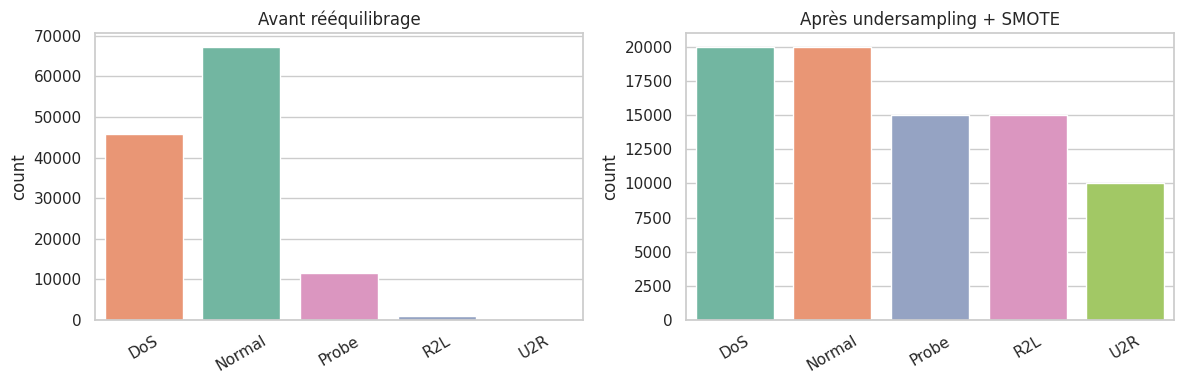

label
0    20000
1    20000
2    15000
3    15000
4    10000
Name: count, dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=y_train.map(dict(enumerate(CLASS_NAMES))), ax=axes[0],
              order=CLASS_NAMES, hue=y_train.map(dict(enumerate(CLASS_NAMES))),
              palette="Set2", legend=False)
axes[0].set_title("Avant rééquilibrage")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("")

undersample = RandomUnderSampler(
    sampling_strategy={CLASS_NAMES.index("Normal"): 20000,
                        CLASS_NAMES.index("DoS"): 20000},
    random_state=42,
)
oversample = SMOTE(
    sampling_strategy={CLASS_NAMES.index("R2L"): 15000,
                        CLASS_NAMES.index("U2R"): 10000,
                        CLASS_NAMES.index("Probe"): 15000},
    k_neighbors=3,
    random_state=42,
)

X_res, y_res = undersample.fit_resample(X_train, y_train)
X_res, y_res = oversample.fit_resample(X_res, y_res)

sns.countplot(x=y_res.map(dict(enumerate(CLASS_NAMES))), ax=axes[1],
              order=CLASS_NAMES, hue=y_res.map(dict(enumerate(CLASS_NAMES))),
              palette="Set2", legend=False)
axes[1].set_title("Après undersampling + SMOTE")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/distribution_classes.png", dpi=120)
plt.show()

print(pd.Series(y_res).value_counts().sort_index())


## 7. Model training & comparison

We train four classifiers on the resampled data and evaluate them on the
**original, untouched** test set (`KDDTest+`), which is the honest way to
measure real-world performance. Besides accuracy, we also track precision,
recall, F1-score, balanced accuracy, Matthews correlation coefficient (MCC),
and Cohen's kappa — useful complements on an imbalanced, multi-class problem.

In [12]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=12, learning_rate=0.1,
        n_jobs=-1, random_state=42, eval_metric="mlogloss"
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=12, learning_rate=0.1,
        class_weight="balanced", n_jobs=-1, random_state=42, verbosity=-1
    ),
}

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
)

predictions = {}
metrics = {}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_pred, average="weighted"),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred),
    }
    print(f"{name:15s} accuracy = {metrics[name]['Accuracy']*100:.2f}%  "
          f"f1 = {metrics[name]['F1-score']*100:.2f}%")

results_df = pd.DataFrame(metrics).T.sort_values("F1-score", ascending=False).round(4)
results_df


Decision Tree   accuracy = 72.10%  f1 = 68.37%


Random Forest   accuracy = 76.28%  f1 = 72.74%


XGBoost         accuracy = 79.56%  f1 = 76.40%


LightGBM        accuracy = 77.19%  f1 = 73.95%


,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,MCC,Kappa
XGBoost,0.7956,0.8376,0.7956,0.7640,0.5935,0.7046,0.6785
LightGBM,0.7719,0.8255,0.7719,0.7395,0.5849,0.6717,0.6400
Random Forest,0.7628,0.8199,0.7628,0.7274,0.5447,0.6586,0.6227
Decision Tree,0.7210,0.7137,0.7210,0.6837,0.5272,0.5915,0.5673


### 7.1 Accuracy comparison

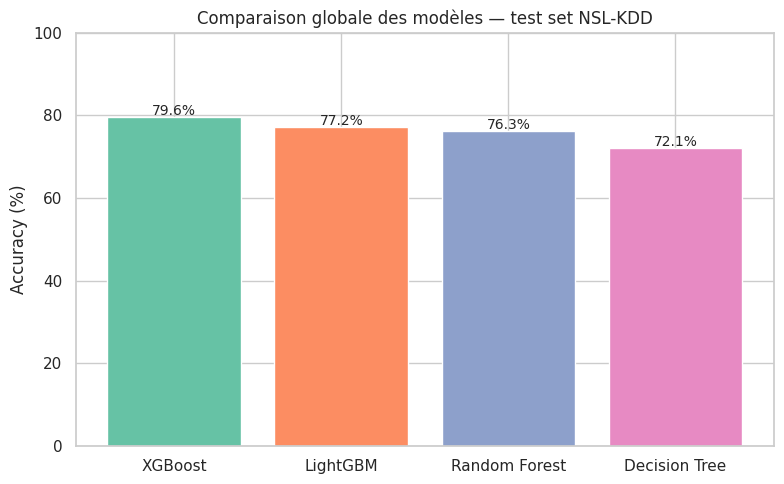

In [13]:
plt.figure(figsize=(8, 5))
acc_sorted = results_df["Accuracy"].sort_values(ascending=False)
bars = plt.bar(acc_sorted.index, acc_sorted.values * 100,
                color=sns.color_palette("Set2", len(acc_sorted)))
for bar, v in zip(bars, acc_sorted.values * 100):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
              ha="center", fontsize=10)
plt.ylabel("Accuracy (%)")
plt.title("Comparaison globale des modèles — test set NSL-KDD")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model_comparison.png", dpi=120)
plt.show()


### 7.2 Multi-metric comparison

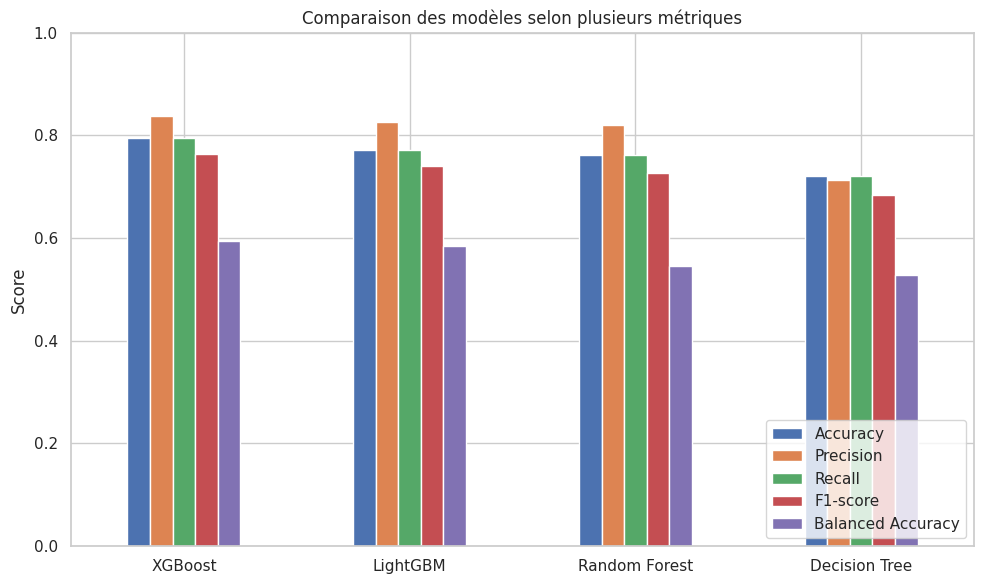

In [14]:
results_df[["Accuracy", "Precision", "Recall", "F1-score", "Balanced Accuracy"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.ylabel("Score")
plt.title("Comparaison des modèles selon plusieurs métriques")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/f1score_comparison.png", dpi=120)
plt.show()


## 8. Detailed evaluation of the best model

In [15]:
best_name = results_df["F1-score"].idxmax()
best_pred = predictions[best_name]
print(f"Best model (by F1-score): {best_name}\n")
print(classification_report(y_test, best_pred, target_names=CLASS_NAMES))


Best model (by F1-score): XGBoost

              precision    recall  f1-score   support

         DoS       0.97      0.84      0.90      7460
      Normal       0.70      0.97      0.82      9711
       Probe       0.82      0.76      0.79      2421
         R2L       0.98      0.13      0.23      2885
         U2R       0.51      0.27      0.35        67

    accuracy                           0.80     22544
   macro avg       0.80      0.59      0.62     22544
weighted avg       0.84      0.80      0.76     22544



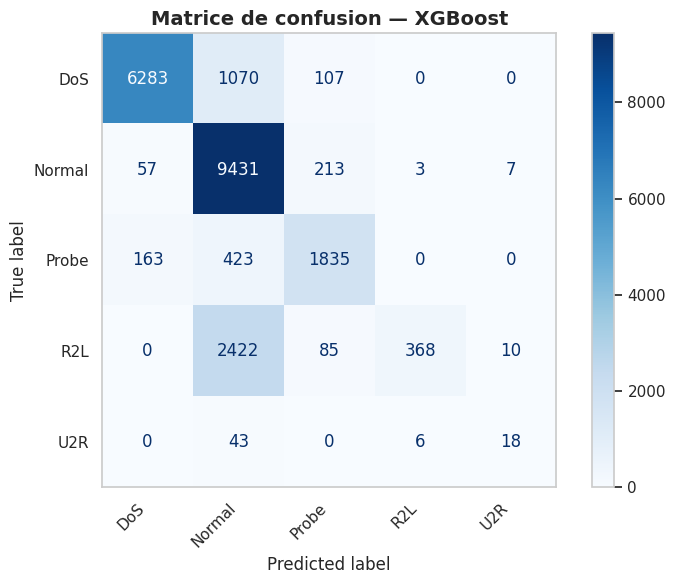

In [16]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.grid(False)
plt.title(f"Matrice de confusion — {best_name}", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix_xgboost.png", dpi=120)
plt.show()


### 8.1 Normalized confusion matrix

Shows the per-class recall directly (row-normalized), which is easier to read when classes are this imbalanced.

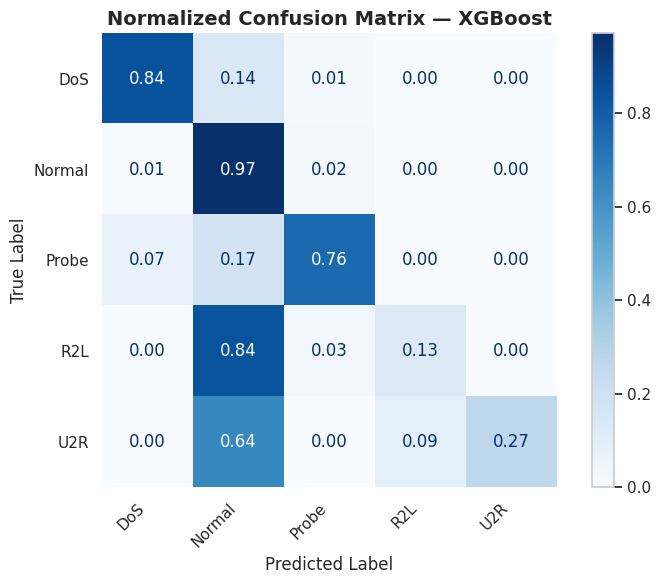

In [17]:
cm_norm = confusion_matrix(y_test, best_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.title(f"Normalized Confusion Matrix — {best_name}", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/normalized_confusion_matrix_XGBoost.png", dpi=120)
plt.show()


**Reading the results:** `Normal` and `DoS` are detected reliably. `R2L`
recall is low because most R2L attacks in the *test* set are types the model
never saw during training (a known NSL-KDD difficulty). `U2R` remains the
hardest class — it has by far the fewest training examples.

## 9. Feature importance (mutual information)

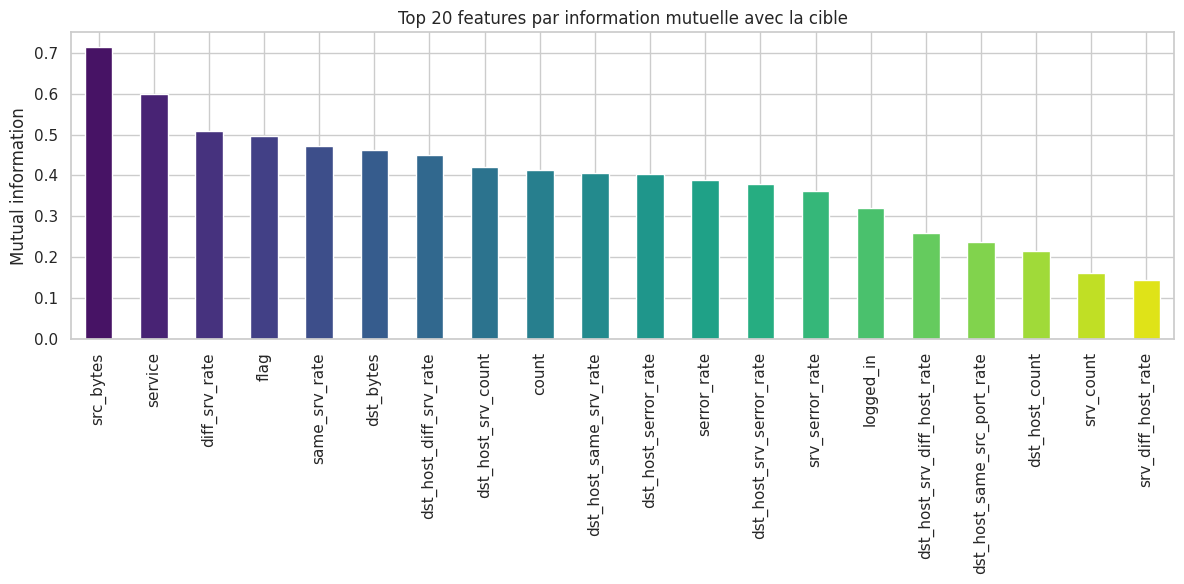

src_bytes                 0.714460
service                   0.599013
diff_srv_rate             0.507932
flag                      0.496891
same_srv_rate             0.472013
dst_bytes                 0.462240
dst_host_diff_srv_rate    0.450939
dst_host_srv_count        0.419961
count                     0.414315
dst_host_same_srv_rate    0.405876
dtype: float64

In [18]:
mutual_info = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mutual_info, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
mi_series.head(20).plot.bar(color=sns.color_palette("viridis", 20))
plt.title("Top 20 features par information mutuelle avec la cible")
plt.ylabel("Mutual information")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance.png", dpi=120)
plt.show()

mi_series.head(10)


## 10. Comparison — all features vs. Mutual-Information selected features

**Objectif :** évaluer la performance de **Random Forest** et **XGBoost** après
équilibrage des classes (SMOTE), en comparant :
- l'entraînement avec **toutes les features** (baseline ci-dessus), et
- l'entraînement avec **uniquement les features les plus importantes**
  (sélectionnées par information mutuelle), pour voir si on peut réduire la
  dimensionnalité sans perdre en performance.

In [19]:
N_TOP_FEATURES = 20
top_features = mi_series.head(N_TOP_FEATURES).index.tolist()
print(f"Top {N_TOP_FEATURES} features (Mutual Information):")
print(top_features)


Top 20 features (Mutual Information):
['src_bytes', 'service', 'diff_srv_rate', 'flag', 'same_srv_rate', 'dst_bytes', 'dst_host_diff_srv_rate', 'dst_host_srv_count', 'count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'serror_rate', 'dst_host_srv_serror_rate', 'srv_serror_rate', 'logged_in', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'dst_host_count', 'srv_count', 'srv_diff_host_rate']


In [20]:
from sklearn.preprocessing import StandardScaler

X_res_selected = X_res[top_features]
X_test_selected = X_test[top_features]

scaler = StandardScaler()
X_res_selected_scaled = scaler.fit_transform(X_res_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)  # transform only -> no data leakage


In [21]:
comparison_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=12, learning_rate=0.1,
        n_jobs=-1, random_state=42, eval_metric="mlogloss"
    ),
}

comparison_results = []

for name, model in comparison_models.items():
    # (a) all features — reuse the metrics already computed above
    acc_all = results_df.loc[name, "Accuracy"]
    f1_all = results_df.loc[name, "F1-score"]

    # (b) Mutual-Information selected features only
    model_sel = type(model)(**model.get_params())
    model_sel.fit(X_res_selected_scaled, y_res)
    y_pred_sel = model_sel.predict(X_test_selected_scaled)
    acc_sel = accuracy_score(y_test, y_pred_sel)
    f1_sel = f1_score(y_test, y_pred_sel, average="weighted")

    comparison_results.append({
        "Model": name,
        "Accuracy (All Features)": acc_all,
        "Accuracy (Selected Features)": acc_sel,
        "F1-score (All Features)": f1_all,
        "F1-score (Selected Features)": f1_sel,
    })
    print(f"{name:15s} | acc all: {acc_all*100:.2f}%  acc top{N_TOP_FEATURES}: {acc_sel*100:.2f}%  "
          f"| f1 all: {f1_all*100:.2f}%  f1 top{N_TOP_FEATURES}: {f1_sel*100:.2f}%")

comparison_df = pd.DataFrame(comparison_results).set_index("Model").round(4)
comparison_df


Random Forest   | acc all: 76.28%  acc top20: 75.15%  | f1 all: 72.74%  f1 top20: 71.03%


XGBoost         | acc all: 79.56%  acc top20: 77.79%  | f1 all: 76.40%  f1 top20: 73.94%


,Accuracy (All Features),Accuracy (Selected Features),F1-score (All Features),F1-score (Selected Features)
Model,,,,
Random Forest,0.7628,0.7515,0.7274,0.7103
XGBoost,0.7956,0.7779,0.7640,0.7394


In [22]:
styled_df = (
    comparison_df.style
    .set_caption("Comparison of Models: All Features vs Selected Features")
    .format("{:.4f}")
    .highlight_max(color="#90EE90")
    .set_properties(**{"text-align": "center", "font-size": "12pt"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1F4E79"), ("color", "white"),
                                      ("font-size", "12pt"), ("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "16pt"), ("font-weight", "bold")]},
    ])
)
styled_df


,Accuracy (All Features),Accuracy (Selected Features),F1-score (All Features),F1-score (Selected Features)
Model,,,,
Random Forest,0.7628,0.7515,0.7274,0.7103
XGBoost,0.7956,0.7779,0.7640,0.7394


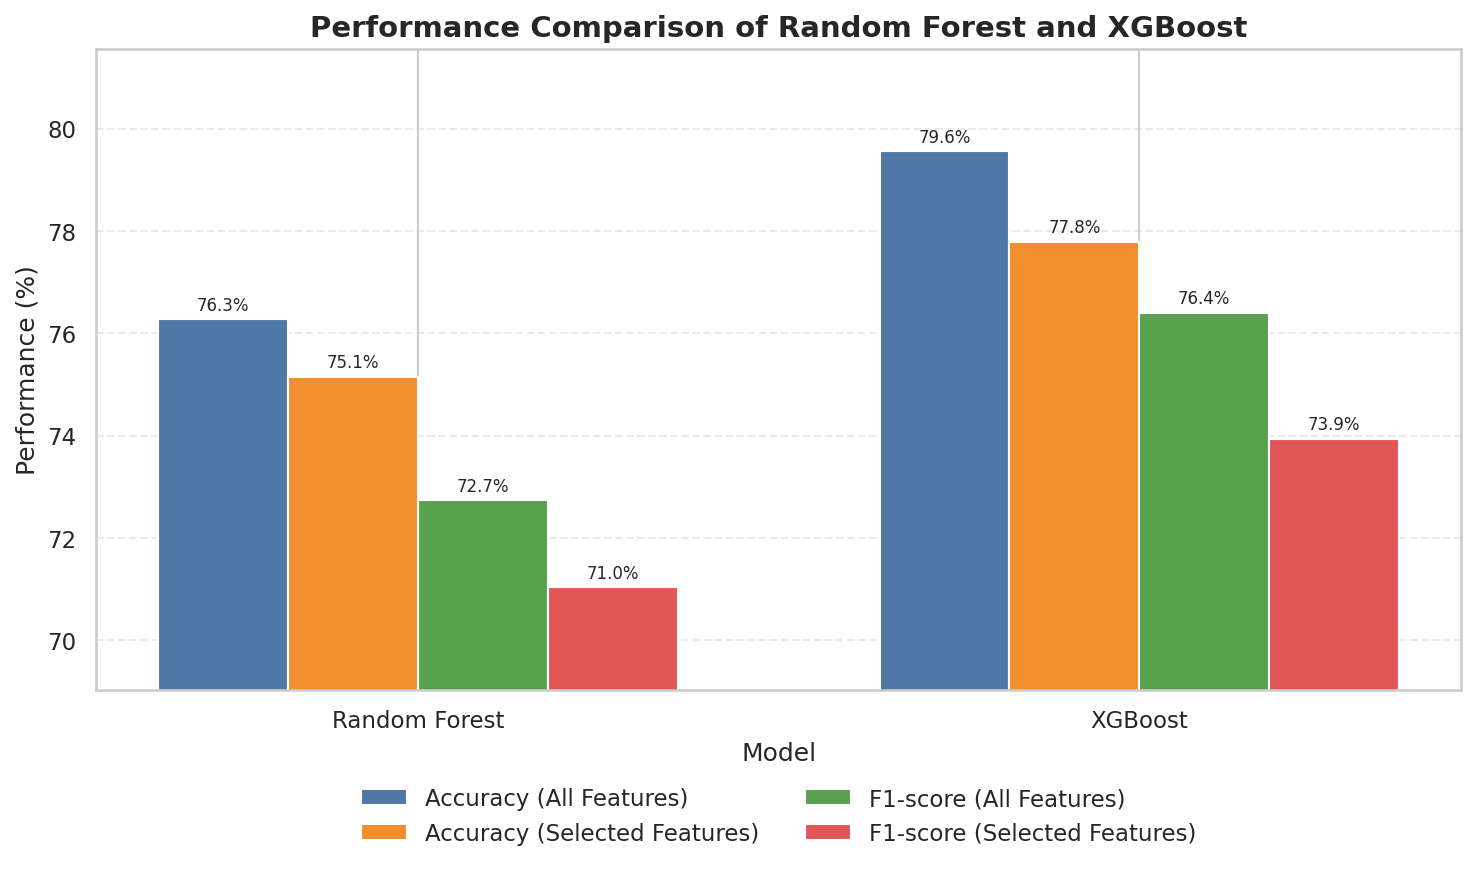

In [23]:
plot_df = comparison_df * 100

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
x = np.arange(len(plot_df.index))
width = 0.18
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]
cols = plot_df.columns

for i, col in enumerate(cols):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, plot_df[col], width, label=col, color=colors[i])
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{h:.1f}%",
                ha="center", va="bottom", fontsize=8)

ax.set_title("Performance Comparison of Random Forest and XGBoost", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Performance (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(plot_df.min().min() - 2, min(plot_df.max().max() + 2, 100))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/comparison_models_ieee.png", dpi=150, bbox_inches="tight")
plt.show()


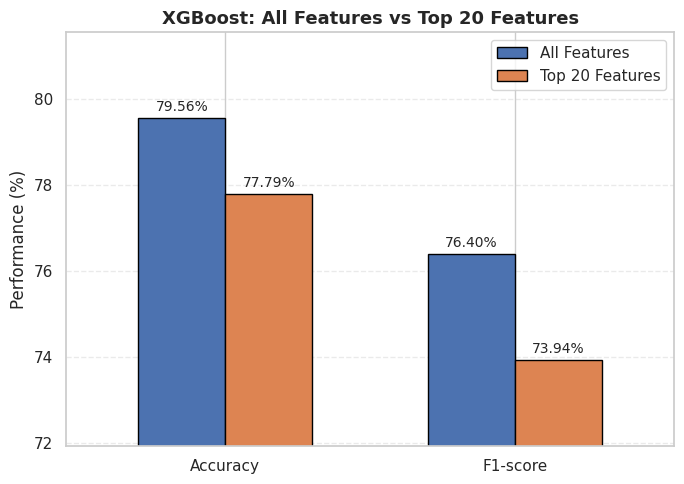

In [24]:
best_row = comparison_df.loc[best_name]

plot_best = pd.DataFrame({
    "All Features": [best_row["Accuracy (All Features)"] * 100, best_row["F1-score (All Features)"] * 100],
    f"Top {N_TOP_FEATURES} Features": [best_row["Accuracy (Selected Features)"] * 100,
                                        best_row["F1-score (Selected Features)"] * 100],
}, index=["Accuracy", "F1-score"])

ax = plot_best.plot(kind="bar", figsize=(7, 5), color=["#4C72B0", "#DD8452"],
                     edgecolor="black", width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=10)

plt.title(f"{best_name}: All Features vs Top {N_TOP_FEATURES} Features", fontsize=13, fontweight="bold")
plt.ylabel("Performance (%)")
plt.xticks(rotation=0)
ymin = plot_best.min().min() - 2
ymax = min(plot_best.max().max() + 2, 100)
plt.ylim(ymin, ymax)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="", loc="upper right")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/xgboost_all_vs_selected.png", dpi=150, bbox_inches="tight")
plt.show()


**Lecture :** réduire les features à celles les plus informatives (via mutual
information) permet de garder une dimensionnalité plus légère tout en restant
proche de la performance obtenue avec les 41 features complètes — un bon
compromis simplicité / performance, surtout utile pour un déploiement temps réel.

## 11. Conclusion

- **SMOTE + undersampling** noticeably helps the model learn minority classes
  (Probe, R2L, U2R) instead of only predicting Normal/DoS.
- **XGBoost / LightGBM** give the best overall trade-off between accuracy and
  minority-class recall among the models tested.
- **R2L and U2R remain the hardest categories** to detect — mainly because the
  NSL-KDD test set intentionally includes attack sub-types absent from
  training, which tests generalization rather than memorization.

### Future work
- Try more recent, representative datasets (CICIDS2017, UNSW-NB15).
- Explore Deep Learning approaches (LSTM, Autoencoder, CNN) for sequence/anomaly
  detection.
- Build a real-time detection pipeline.
